In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis


# Load Dataset

In [2]:
# Read Excel file
df_date = pd.read_excel("Dataset Sirbu/DataPrelievo.xlsx")

print(df_date.head())
print(df_date.info())

   Number Data prelievo
0       1    2003-08-25
1       2    2010-10-19
2       3    2004-01-09
3       4    1994-01-24
4       5    2003-10-28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8065 entries, 0 to 8064
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Number         8065 non-null   int64         
 1   Data prelievo  8065 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 126.1 KB
None


In [3]:
# Read Excel file
df_update = pd.read_excel("Dataset Sirbu/Creatinina_AltriEsamiCorretti.xlsx")

# Show first 5 rows
print(df_update.head())
print(df_update.info())

   Number  Total cholesterol   HDL    LDL  Triglycerides  Creatinina
0       1              196.0  52.0  118.0          130.0        0.83
1       2              123.0  43.0   71.0           45.0        0.80
2       3              248.0  37.0  180.0          157.0        1.01
3       4                NaN   NaN    NaN            NaN         NaN
4       5              139.0  33.0   81.0          126.0        1.59
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8065 entries, 0 to 8064
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Number             8065 non-null   int64  
 1   Total cholesterol  7705 non-null   float64
 2   HDL                7455 non-null   float64
 3   LDL                7433 non-null   float64
 4   Triglycerides      7627 non-null   float64
 5   Creatinina         7469 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 378.2 KB
None


In [4]:
# Read Excel file
df_main = pd.read_excel("Dataset Sirbu/OrmoniTiroidei3Aprile2024.xlsx")

# Show first 5 rows
print(df_main.head())
print(df_main.info())

   Number  Gender (Male = 1)        Age  Total cholesterol   HDL    LDL  \
0     1.0                1.0  56.033708              196.0  52.0  118.0   
1     2.0                1.0  62.898876              123.0  43.0   71.0   
2     3.0                1.0  60.876404              248.0  37.0  180.0   
3     4.0                1.0  75.396067                NaN   NaN    NaN   
4     5.0                1.0  80.803371              139.0  33.0   81.0   

   Triglycerides  Glycemia   TSH   fT3  ...  Total mortality  CVD Death  \
0          130.0     104.0  1.26  2.72  ...              0.0        0.0   
1           45.0     220.0  0.73  2.78  ...              0.0        0.0   
2          157.0      87.0  1.65  1.74  ...              0.0        0.0   
3            NaN       NaN  0.40  7.20  ...              1.0        1.0   
4          126.0     103.0  7.32  2.22  ...              1.0        1.0   

   Fatal MI or Sudden death  UnKnown  Accident  Suicide      CABG   \
0                       0.0 

## Merging datasets

In [5]:
cols = ['Total cholesterol', 'HDL', 'LDL', 'Triglycerides']
df1_aligned = df_main.set_index('Number')
df2_aligned = df_update.set_index('Number')

common_index = df1_aligned.index.intersection(df2_aligned.index)

df1_aligned = df1_aligned.loc[common_index, cols]
df2_aligned = df2_aligned.loc[common_index, cols]

diff_mask = df1_aligned[cols] != df2_aligned[cols]

rows_with_diff = diff_mask.any(axis=1)

print(rows_with_diff[rows_with_diff])

Number
4.0       True
10.0      True
17.0      True
19.0      True
26.0      True
          ... 
7942.0    True
7943.0    True
7944.0    True
7945.0    True
8043.0    True
Length: 1192, dtype: bool


In [6]:
# Set index
df_main = df_main.set_index('Number')
df_update = df_update.set_index('Number')

# Keep index name safe
df_main.index.name = 'Number'
df_update.index.name = 'Number'

# Columns to update
cols_to_update = df_update.columns.intersection(df_main.columns)

# Update shared columns
df_main.update(df_update[cols_to_update])

# Add new columns
new_cols = df_update.columns.difference(df_main.columns)
df_main = df_main.join(df_update[new_cols])

# Reset index safely
df_main = df_main.reset_index()
df_update = df_update.reset_index()

In [7]:
df_main = df_main.merge(
    df_date[['Number', 'Data prelievo']],  
    on='Number',
    how='left' 
)

In [8]:
print(df_main.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8144 entries, 0 to 8143
Data columns (total 85 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Number                                      8065 non-null   float64       
 1   Gender (Male = 1)                           8065 non-null   float64       
 2   Age                                         8065 non-null   float64       
 3   Total cholesterol                           7705 non-null   float64       
 4   HDL                                         7455 non-null   float64       
 5   LDL                                         7433 non-null   float64       
 6   Triglycerides                               7627 non-null   float64       
 7   Glycemia                                    7651 non-null   float64       
 8   TSH                                         8065 non-null   float64       
 9   fT3     

In [9]:
print(df_main.describe())

            Number  Gender (Male = 1)          Age  Total cholesterol  \
count  8065.000000        8065.000000  8065.000000        7705.000000   
mean   4033.000000           0.658648    68.266614         183.750811   
min       1.000000           0.000000    13.851124          55.000000   
25%    2017.000000           0.000000    60.393258         153.000000   
50%    4033.000000           1.000000    69.904494         182.000000   
75%    6049.000000           1.000000    77.691011         210.000000   
max    8065.000000           1.000000   100.727528         605.000000   
std    2328.309294           0.474193    13.044562          44.423738   

               HDL          LDL  Triglycerides     Glycemia          TSH  \
count  7455.000000  7433.000000    7627.000000  7651.000000  8065.000000   
mean     42.325017   116.262855     123.750229   108.277480     2.133385   
min       6.000000    13.000000       9.000000     1.000000     0.010000   
25%      34.000000    91.000000      7

In [10]:
print(df_main["Documented resting \nor exertional ischemia"].nlargest(5))
df_main.loc[8143, "Documented resting \nor exertional ischemia"] = 1
print(df_main["Documented resting \nor exertional ischemia"].nlargest(5))

8143    5311.0
0          1.0
2          1.0
3          1.0
4          1.0
Name: Documented resting \nor exertional ischemia, dtype: float64
0    1.0
2    1.0
3    1.0
4    1.0
5    1.0
Name: Documented resting \nor exertional ischemia, dtype: float64


### Checking consistency of dataset

In [11]:
df_main = df_main.dropna(subset=['Number'])

df_main['Data prelievo'] = pd.to_datetime(df_main['Data prelievo'])
df_main['Follow Up Data'] = pd.to_datetime(df_main['Follow Up Data'])

print((df_main['Data prelievo'] <= df_main['Follow Up Data']).all())

True


In [12]:
violations = df_main[
    ((df_main["Total mortality"] == 0) & (df_main["Data of death"].notna())) |
    ((df_main["Total mortality"] != 0) & (df_main["Data of death"].isna()))
]

print(violations["Total mortality"])
print(violations["Data of death"])

df_main.loc[7285, "Total mortality"] = 1
df_main.loc[7285, "UnKnown"] = 1

print(df_main.iloc[7285][["Total mortality", "UnKnown"]])

7285    0.0
Name: Total mortality, dtype: float64
7285   2012-10-11
Name: Data of death, dtype: datetime64[ns]
Total mortality    1.0
UnKnown            1.0
Name: 7285, dtype: object


# Feature importance analysis

### Transform data to time to event and binary event


In [13]:
df_main["Follow Up Data"] = (
    df_main["Follow Up Data"] - df_main["Data prelievo"]
).dt.days

df_main["Data of death"] = (
    df_main["Data of death"] - df_main["Data prelievo"]
).dt.days
df_main["Data of death"] = df_main["Data of death"].fillna(0)


target = ["CABG " ,"Non Fatal AMI (Follow-Up)","Ictus","PCI"]

for t in target:
    df_main[t+"_event"] = df_main[t].notna().astype(int)

    df_main[t] = (
        df_main[t] - df_main["Data prelievo"]
    ).dt.days

    df_main[t] = df_main[t].fillna(0)

print(df_main.info())
print(df_main.head())



<class 'pandas.core.frame.DataFrame'>
Index: 8065 entries, 0 to 8064
Data columns (total 89 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Number                                      8065 non-null   float64       
 1   Gender (Male = 1)                           8065 non-null   float64       
 2   Age                                         8065 non-null   float64       
 3   Total cholesterol                           7705 non-null   float64       
 4   HDL                                         7455 non-null   float64       
 5   LDL                                         7433 non-null   float64       
 6   Triglycerides                               7627 non-null   float64       
 7   Glycemia                                    7651 non-null   float64       
 8   TSH                                         8065 non-null   float64       
 9   fT3          

### Missing values

In [14]:
missing = df_main.isna().sum().sort_values(ascending=False)
missing_percent = (df_main.isna().mean()*100).sort_values(ascending=False)

missing_table = pd.concat([missing, missing_percent], axis=1)
missing_table.columns = ["Missing Values", "Percentage"]

print(missing_table.head(20))

                          Missing Values  Percentage
Cause of death                      5659   70.167390
Collected by                        5658   70.154991
vsx                                  710    8.803472
LDL                                  632    7.836330
HDL                                  610    7.563546
Creatinina                           596    7.389957
BMI                                  573    7.104774
Height                               496    6.150031
Triglycerides                        438    5.430874
Glycemia                             414    5.133292
Weight                               414    5.133292
Total cholesterol                    360    4.463732
DimPP                                345    4.277743
DimSettoIV                           324    4.017359
WmsiBas                              223    2.765034
Systolic blood pressure              161    1.996280
Diastolic blood pressure             161    1.996280
Antidiabetici                        131    1.

In [15]:
df_main = df_main.drop(columns=["Collected by", "Cause of death","CardiopatiaCongenita"])
print(df_main.shape)
df_main = df_main.dropna()
print(df_main.shape)

(8065, 86)
(6264, 86)


### Correlation

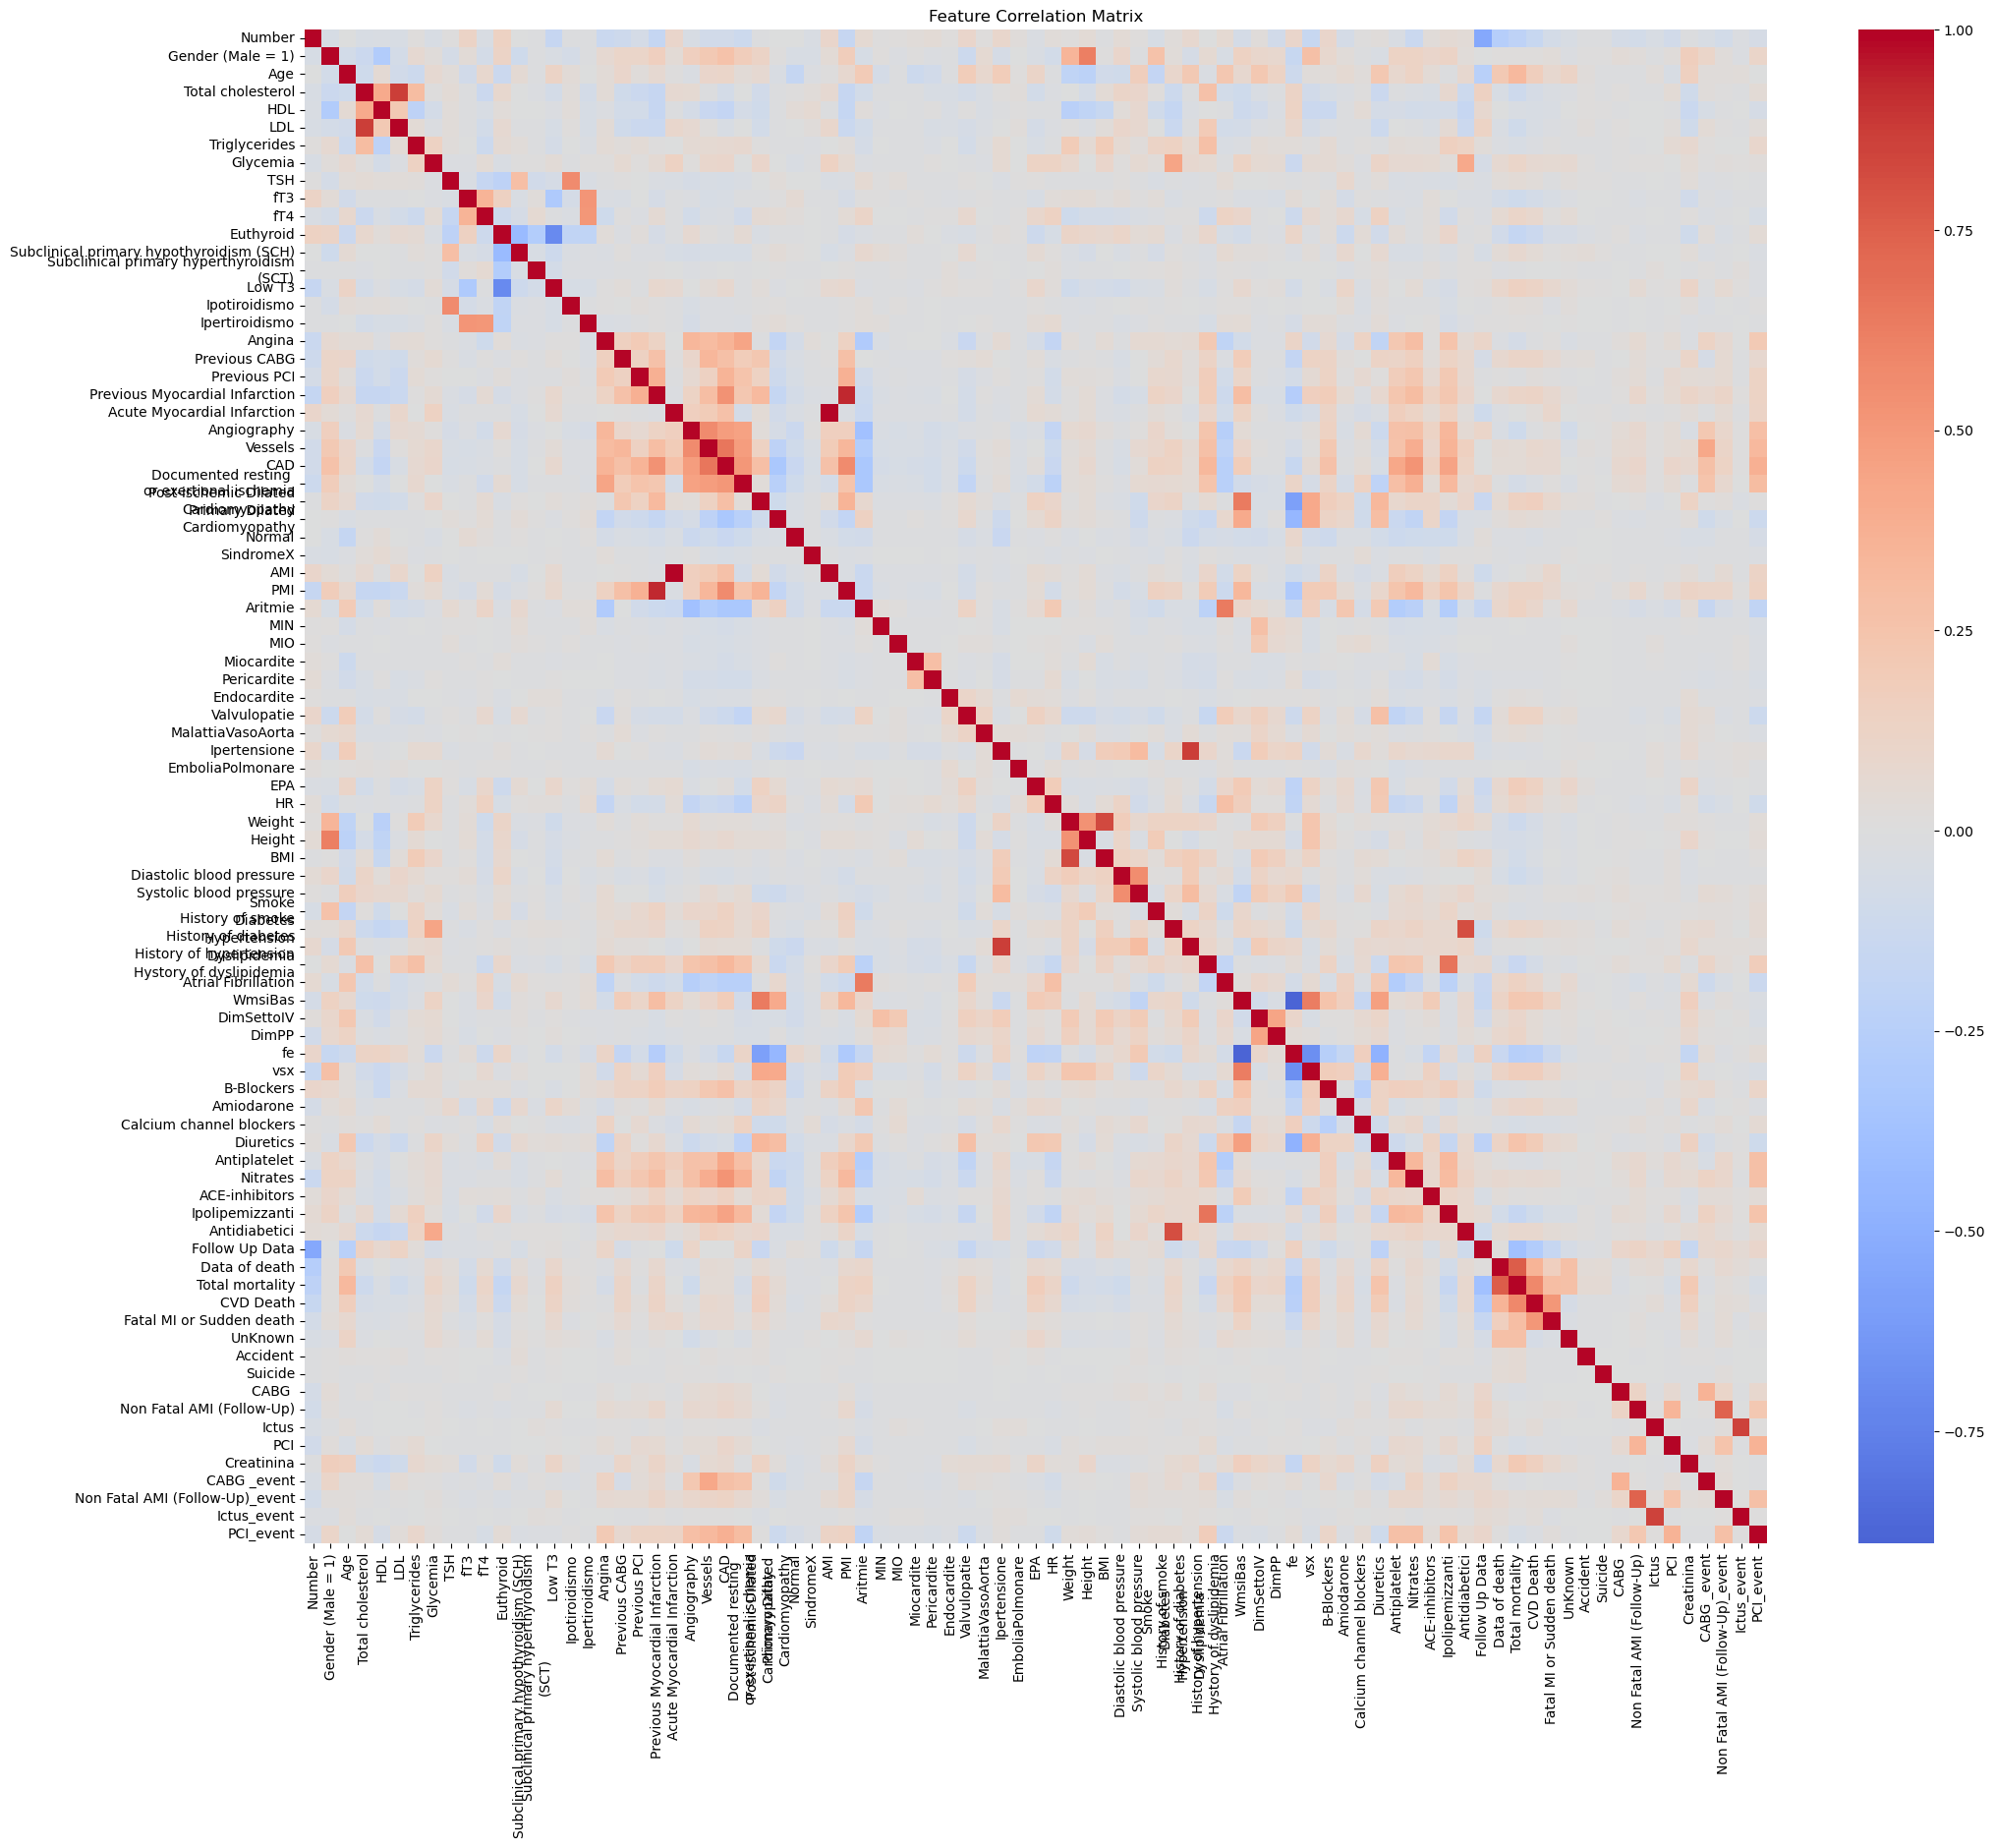

In [16]:
numeric_df = df_main.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [17]:
corr_threshold = 0.90

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [column for column in upper.columns if any(upper[column] > corr_threshold)]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['AMI', 'PMI']


# Time-to-event

### Mortality

In [18]:
binary_cols = [
    col for col in df_main.columns
    if set(df_main[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'Total mortality', 'CVD Death', 'Fatal MI or Sudden death', 'UnKnown', 'Acc

In [19]:
# To avoid data leakage, we should not include features that are directly related to the target variable. 
# In this case, we will drop the columns that are related to mortality and cause of death, 
# as they would provide direct information about the outcome we are trying to predict.
df_mortality = df_main.copy()

cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo"]

tmp = df_mortality[cols_to_keep].copy()

df_mortality = df_mortality.drop(columns=cols_to_keep)

# Standardize continuous features
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_mortality)

df_mortality = pd.DataFrame(scaled_array, columns=df_mortality.columns, index=df_mortality.index)

df_mortality = pd.concat([df_mortality, tmp], axis=1)

df_mortality = df_mortality.drop(columns=[   "Data of death",
                                        "Fatal MI or Sudden death",  
                                        "UnKnown", 
                                        "Accident",
                                        "Suicide",
                                        "Number",
                                        "CVD Death",
                                        "Data prelievo"])

print(df_mortality.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6264 entries, 0 to 8064
Data columns (total 78 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         6264 non-null   float64
 1   Total cholesterol                           6264 non-null   float64
 2   HDL                                         6264 non-null   float64
 3   LDL                                         6264 non-null   float64
 4   Triglycerides                               6264 non-null   float64
 5   Glycemia                                    6264 non-null   float64
 6   TSH                                         6264 non-null   float64
 7   fT3                                         6264 non-null   float64
 8   fT4                                         6264 non-null   float64
 9   Vessels                                     6264 non-null   float64
 10  HR               

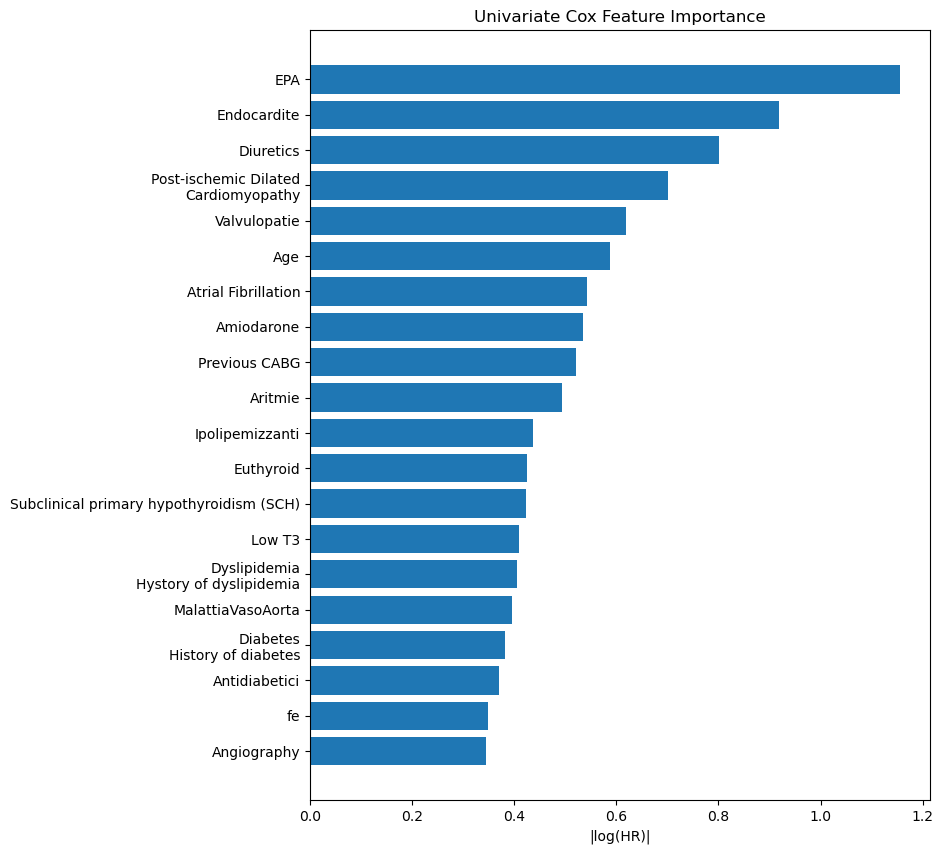

In [20]:
results = []
for c in df_mortality.columns: 
    if c not in ["Follow Up Data", "Total mortality"]:
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(
            df_mortality[[c,'Follow Up Data','Total mortality']], 
            duration_col='Follow Up Data', 
            event_col='Total mortality')
        coef = cph.summary.loc[c, "coef"]
        se = cph.summary.loc[c, "se(coef)"]
        p = cph.summary.loc[c, "p"]
        results.append({"feature": c, "coef": coef, "se": se, "p": p})

importance = pd.DataFrame(results)
importance_temp = importance[importance["p"] < 0.05].copy()

importance["abs_logHR"] = importance["coef"].abs()
importance = importance[importance["p"] < 0.05]
importance = importance.sort_values("abs_logHR", ascending=False).head(20)

plt.figure(figsize=(8,10))
plt.barh(importance["feature"], importance["abs_logHR"])
plt.gca().invert_yaxis()
plt.xlabel("|log(HR)|")
plt.title("Univariate Cox Feature Importance")
plt.show()

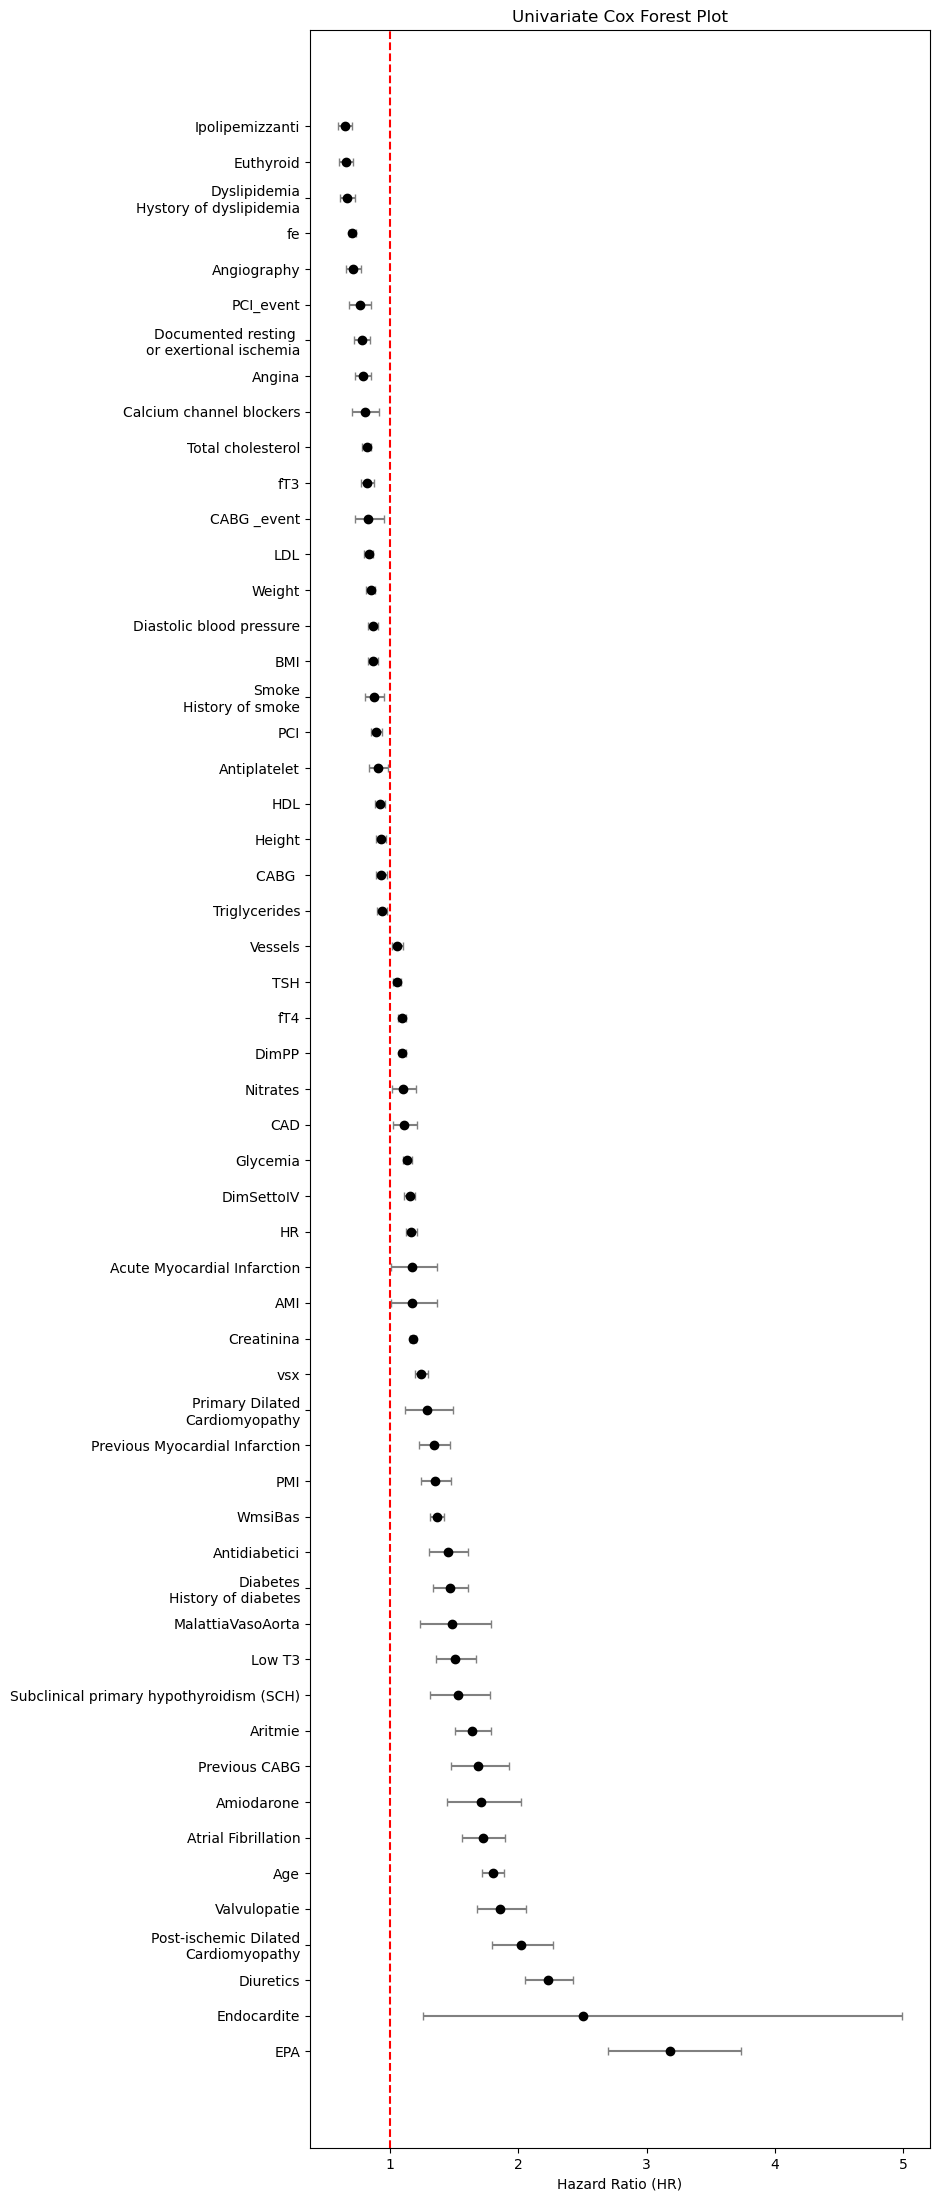

In [21]:
# Calculate HR and 95% CI
importance_temp["HR"] = np.exp(importance_temp["coef"])
importance_temp["HR_lower"] = np.exp(importance_temp["coef"] - 1.96*importance_temp["se"])
importance_temp["HR_upper"] = np.exp(importance_temp["coef"] + 1.96*importance_temp["se"])

# Sort by HR
importance_temp = importance_temp.sort_values("HR")

# Plot forest plot
plt.figure(figsize=(8, len(importance_temp)*0.5))
plt.errorbar(
    importance_temp["HR"],
    range(len(importance_temp)),
    xerr=[importance_temp["HR"] - importance_temp["HR_lower"], importance_temp["HR_upper"] - importance_temp["HR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
plt.yticks(range(len(importance_temp)), importance_temp["feature"])
plt.axvline(x=1, color='red', linestyle='--')  # no-effect line
plt.xlabel("Hazard Ratio (HR)")
plt.title("Univariate Cox Forest Plot")
plt.gca().invert_yaxis()
plt.show()

Concordance Index: 0.7979708186758632


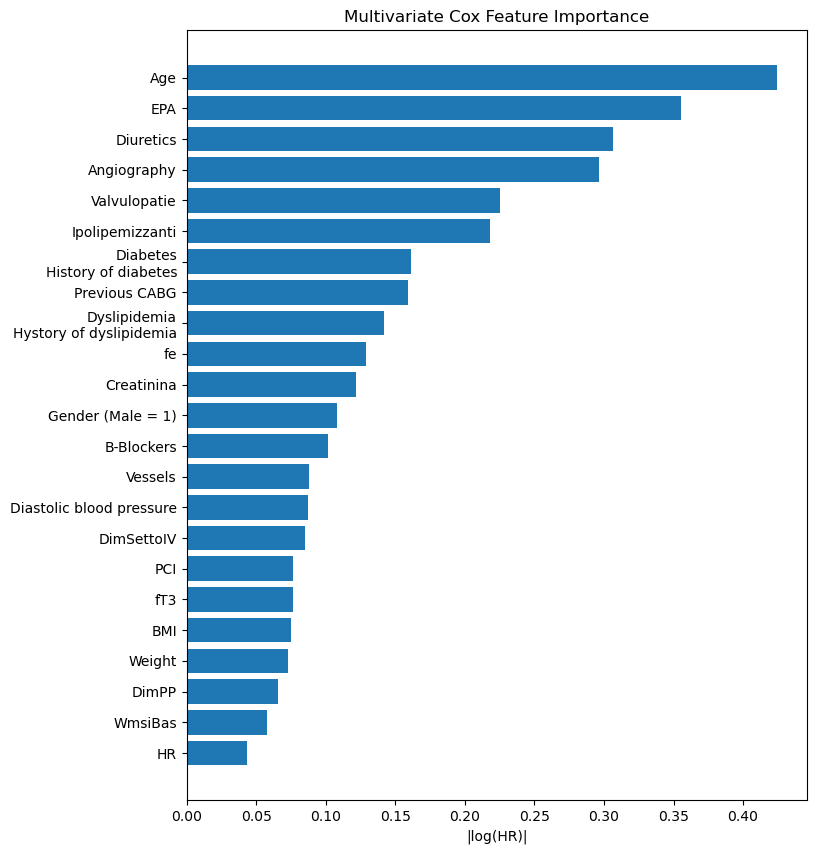

In [22]:
# Columns to use as covariates (exclude duration/event)
#covariates = [c for c in df_mortality.columns if c not in ['Data of death', 'Total mortality']]

# Fit multivariate Cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_mortality,#[covariates],# + ['Data of death', 'Total mortality']], 
        duration_col='Follow Up Data', 
        event_col='Total mortality')

print("Concordance Index:", cph.concordance_index_)

# Extract results
importance = cph.summary.reset_index()
importance.rename(columns={'index':'feature'}, inplace=True)

# Keep only significant features
importance = importance[importance["p"] < 0.05].copy()
importance_temp = importance.copy()

# Calculate |log(HR)|
importance["abs_logHR"] = importance["coef"].abs()

# Sort by |log(HR)| for plotting
importance = importance.sort_values("abs_logHR", ascending=False)  # top 20 if needed: .head(20)

# Plot |log(HR)|
plt.figure(figsize=(8,10))
plt.barh(importance["covariate"], importance["abs_logHR"])
plt.gca().invert_yaxis()
plt.xlabel("|log(HR)|")
plt.title("Multivariate Cox Feature Importance")
plt.show()

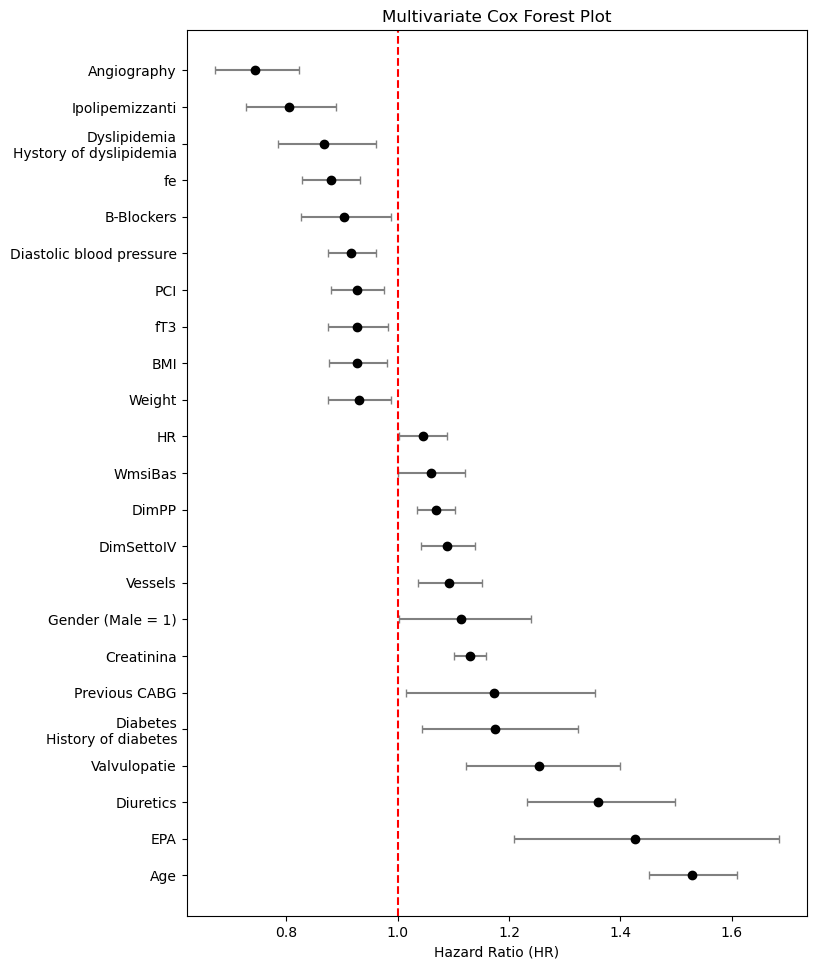

In [23]:
# Calculate HR and 95% CI
importance_temp["HR"] = np.exp(importance_temp["coef"])
importance_temp["HR_lower"] = np.exp(importance_temp["coef"] - 1.96*importance_temp["se(coef)"])
importance_temp["HR_upper"] = np.exp(importance_temp["coef"] + 1.96*importance_temp["se(coef)"])

# Sort by HR for plotting
importance_temp = importance_temp.sort_values("HR")

# Plot forest plot
plt.figure(figsize=(8, len(importance_temp)*0.5))
plt.errorbar(
    importance_temp["HR"],
    range(len(importance_temp)),
    xerr=[importance_temp["HR"] - importance_temp["HR_lower"], importance_temp["HR_upper"] - importance_temp["HR"]],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)
plt.yticks(range(len(importance_temp)), importance_temp["covariate"])
plt.axvline(x=1, color='red', linestyle='--') 
plt.xlabel("Hazard Ratio (HR)")
plt.title("Multivariate Cox Forest Plot")
plt.gca().invert_yaxis()
plt.show()

##### DEEPSURV

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch

# Assume 'T' = duration column, 'E' = event indicator
T = df_mortality["Follow Up Data"]         
E = df_mortality["Total mortality"]
X = df_mortality.drop(columns=["Follow Up Data", "Total mortality"]) 

# Standardize numerical features (keeping DataFrame)
#scaler = StandardScaler()
#X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train/test split (still as DataFrames / Series)
X_train, X_test, T_train, T_test, E_train, E_test = train_test_split(
    X, T, E, test_size=0.2, random_state=42
)

# Convert DataFrames / Series to torch tensors for pycox
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
T_train_tensor = torch.tensor(T_train.values, dtype=torch.float32)
E_train_tensor = torch.tensor(E_train.values, dtype=torch.float32)
T_test_tensor = torch.tensor(T_test.values, dtype=torch.float32)
E_test_tensor = torch.tensor(E_test.values, dtype=torch.float32)

In [25]:
import torchtuples as tt
from pycox.models import CoxPH
import torch
from torch import nn

# Network definition
in_features = X_train.shape[1]
num_nodes = [32, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(in_features, num_nodes, 1, batch_norm=True, dropout=dropout, activation=nn.ReLU)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# DeepSurv model
model = CoxPH(net, tt.optim.AdamWR)

In [27]:
# Prepare dataset for pycox
#from pycox.preprocessing.label_transforms import LabTransCoxPH

# DeepSurv uses Cox PH loss, no need to transform labels
# But pycox allows easy handling of mini-batches

# Convert to torch tensors
#X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
#X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
#T_train_tensor = torch.tensor(T_train, dtype=torch.float32)
#E_train_tensor = torch.tensor(E_train, dtype=torch.float32)

# Fit model
epochs = 100
batch_size = 128

model.fit(X_train_tensor, (T_train_tensor, E_train_tensor), batch_size, epochs, verbose=True)

/opt/miniconda3/lib/python3.13/site-packages/torchtuples/callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1728232383339/work/torch/csrc/utils/python_arg_parser.cpp:1581.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[3s / 3s],		train_loss: 4.3287
1:	[0s / 4s],		train_loss: 4.0922
2:	[0s / 4s],		train_loss: 3.9540
3:	[0s / 4s],		train_loss: 3.9152
4:	[2s / 7s],		train_loss: 3.8389
5:	[0s / 7s],		train_loss: 3.7636
6:	[0s / 7s],		train_loss: 3.7827
7:	[0s / 7s],		train_loss: 3.7707
8:	[0s / 8s],		train_loss: 3.7453
9:	[0s / 8s],		train_loss: 3.7200
10:	[0s / 8s],		train_loss: 3.7233
11:	[0s / 8s],		train_loss: 3.6990
12:	[0s / 8s],		train_loss: 3.6925
13:	[0s / 8s],		train_loss: 3.6811
14:	[0s / 9s],		train_loss: 3.6884
15:	[0s / 9s],		train_loss: 3.6700
16:	[0s / 9s],		train_loss: 3.6634
17:	[0s / 9s],		train_loss: 3.6707
18:	[0s / 9s],		train_loss: 3.6259
19:	[0s / 9s],		train_loss: 3.6280
20:	[0s / 9s],		train_loss: 3.6330
21:	[0s / 9s],		train_loss: 3.6331
22:	[0s / 10s],		train_loss: 3.6409
23:	[0s / 10s],		train_loss: 3.6260
24:	[0s / 10s],		train_loss: 3.5861
25:	[0s / 10s],		train_loss: 3.5871
26:	[0s / 10s],		train_loss: 3.5875
27:	[0s / 10s],		train_loss: 3.6074
28:	[0s / 10s],		train_l

In [31]:
# Concordance index
from pycox.evaluation import EvalSurv

# Predict log-risk for test set
risk_scores = model.predict(X_test_tensor)

# Convert to survival function
# For Cox, higher risk score = higher hazard
# EvalSurv can compute C-index
import numpy as np

# Use Kaplan-Meier baseline estimate
baseline_hazard = model.compute_baseline_hazards()
surv = model.predict_surv_df(X_test_tensor)

# Concordance index
from pycox.evaluation import EvalSurv
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')
c_index = ev.concordance_td()
print("C-index:", c_index)

C-index: 0.766960841267467


## Cardiovascular Mortality

In [38]:
df_cardiovascular = df_main.copy()
df_cardiovascular["Other deaths"] = df_cardiovascular["Total mortality"] - df_cardiovascular["CVD Death"]
df_cardiovascular["death"] = 0
df_cardiovascular.loc[df_cardiovascular["CVD Death"] == 1, "death"] = 1
df_cardiovascular.loc[df_cardiovascular["Other deaths"] == 1, "death"] = 2

In [39]:
df_cardiovascular["death"].value_counts()

death
0    4632
2     960
1     672
Name: count, dtype: int64

In [40]:
binary_cols = [
    col for col in df_cardiovascular.columns
    if set(df_cardiovascular[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'Total mortality', 'CVD Death', 'Fatal MI or Sudden death', 'UnKnown', 'Acc

In [41]:
cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo","death"]

tmp = df_cardiovascular[cols_to_keep].copy()

df_cardiovascular = df_cardiovascular.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_cardiovascular)

df_cardiovascular = pd.DataFrame(scaled_array, columns=df_cardiovascular.columns, index=df_cardiovascular.index)

df_cardiovascular = pd.concat([df_cardiovascular, tmp], axis=1)

df_cardiovascular = df_cardiovascular.drop(columns=[ "Fatal MI or Sudden death",  
                                            "UnKnown",
                                            "Total mortality", 
                                            "Accident",
                                            "Suicide",
                                            "Number",
                                            "Data prelievo",
                                            "CVD Death",
                                            "Other deaths",
                                            "Data of death"
                                             ])

print(df_cardiovascular.info())
print(df_cardiovascular["death"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 6264 entries, 0 to 8064
Data columns (total 78 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         6264 non-null   float64
 1   Total cholesterol                           6264 non-null   float64
 2   HDL                                         6264 non-null   float64
 3   LDL                                         6264 non-null   float64
 4   Triglycerides                               6264 non-null   float64
 5   Glycemia                                    6264 non-null   float64
 6   TSH                                         6264 non-null   float64
 7   fT3                                         6264 non-null   float64
 8   fT4                                         6264 non-null   float64
 9   Vessels                                     6264 non-null   float64
 10  HR               

In [42]:
df_cardiovascular["death"].value_counts()

death
0    4632
2     960
1     672
Name: count, dtype: int64

In [73]:
df_temp = df_cardiovascular.copy()
df_temp["death"] = df_temp["death"] == 1

# initialize CoxPHFitter
cph_cv = CoxPHFitter(penalizer=0.1)

# fit
cph_cv.fit(df_temp, duration_col="Follow Up Data", event_col="death")

<lifelines.CoxPHFitter: fitted with 6264 total observations, 5592 right-censored observations>

In [74]:
df_temp = df_cardiovascular.copy()
df_temp["death"] = df_temp["death"] == 2

# initialize CoxPHFitter
cph_other = CoxPHFitter(penalizer=0.1)

# fit
cph_other.fit(df_temp, duration_col="Follow Up Data", event_col="death")

<lifelines.CoxPHFitter: fitted with 6264 total observations, 5304 right-censored observations>

In [75]:
print("Concordance index CV: ", cph_cv.concordance_index_)
print("Concordance index Other: ", cph_other.concordance_index_)

Concordance index CV:  0.820316337589739
Concordance index Other:  0.7940172485243494


                                       CV death  Other death    CV death p  \
covariate                                                                    
Age                                    1.246505     1.499317  2.593948e-12   
LDL                                    0.994590     0.937531  8.668673e-01   
Glycemia                               1.014749     1.060965  5.847583e-01   
Vessels                                1.096025     1.029143  3.209861e-03   
Weight                                 0.943477     0.927238  8.075659e-02   
BMI                                    0.961249     0.916983  2.136326e-01   
Diastolic blood pressure               0.935956     0.924067  2.481326e-02   
WmsiBas                                1.099905     1.036308  3.374890e-03   
DimSettoIV                             1.067934     1.086658  2.542282e-02   
DimPP                                  1.040164     1.075336  1.796169e-01   
fe                                     0.859583     0.938363  5.

<Axes: xlabel='covariate'>

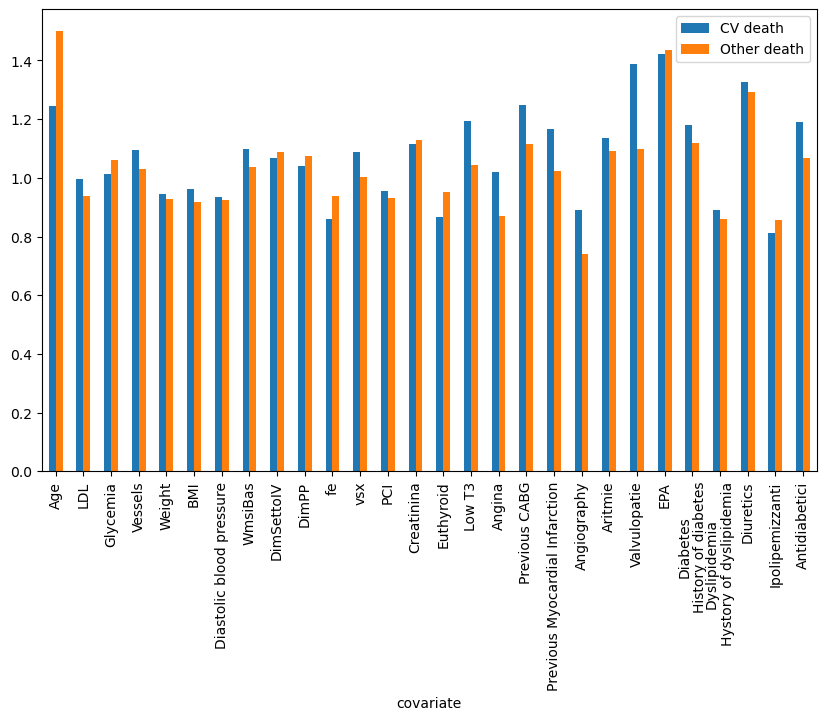

In [76]:
coef_cv = cph_cv.summary["exp(coef)"]
coef_other = cph_other.summary["exp(coef)"]
p_cv = cph_cv.summary["p"]
p_other = cph_other.summary["p"]

significant = (
    (p_cv < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "CV death": coef_cv,
    "Other death": coef_other,
    "CV death p": p_cv,
    "Other death p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["CV death","Other death"]].plot.bar(figsize=(10,6))

##### DEEPHIT

In [50]:
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pycox.models import DeepHitSingle
import torchtuples as tt
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load and prepare data
# ------------------------------

# Columns: T = duration, E = event type (0 = censored, 1,2,... = competing risks)
T = df_cardiovascular["Follow Up Data"]
E = df_cardiovascular["death"]
X = df_cardiovascular.drop(columns=["Follow Up Data", "death"])

# Standardize features
#scaler = StandardScaler()
#X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train/test split
X_train, X_test, T_train, T_test, E_train, E_test = train_test_split(
    X, T, E, test_size=0.2, random_state=42
)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
T_train_tensor = torch.tensor(T_train.values, dtype=torch.float32)
E_train_tensor = torch.tensor(E_train.values, dtype=torch.int64)
T_test_tensor = torch.tensor(T_test.values, dtype=torch.float32)
E_test_tensor = torch.tensor(E_test.values, dtype=torch.int64)

# ------------------------------
# 2. Define DeepHit network
# ------------------------------

#from pycox.preprocessing.feature_transforms import StandardScaler
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

# Choose number of discrete time intervals
num_durations = 100  # can also try 200

labtrans = LabTransDiscreteTime(num_durations)

# Fit and transform train labels
y_train = labtrans.fit_transform(T_train.values, E_train.values)
y_test = labtrans.transform(T_test.values, E_test.values)

# Now the number of output nodes = labtrans.out_features
out_features = labtrans.out_features
print("Network output nodes needed:", out_features)  # should be 100

in_features = X_train.shape[1]
num_nodes = [64, 32]  # hidden layers
dropout = 0.1

net = tt.practical.MLPVanilla(
    in_features, num_nodes, out_features = out_features ,  # output nodes for discretized times
    batch_norm=True, dropout=dropout, activation=torch.nn.ReLU
)

# Optimizer
optimizer = tt.optim.AdamWR(lr=0.01)

# Define DeepHit model
model = DeepHitSingle(net, tt.optim.AdamWR, duration_index=labtrans.cuts)  # duration_index will be inferred automatically

# ------------------------------
# 3. Train model
# ------------------------------
epochs = 50
batch_size = 128

log = model.fit(
    X_train_tensor, 
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=True
)

# ------------------------------
# 4. Predict survival functions
# ------------------------------
surv = model.predict_surv_df(X_test_tensor)  # returns survival probability over discretized times

# ------------------------------
# 5. Evaluate model
# ------------------------------
# For competing risks, we evaluate CIF for each event type
ev = EvalSurv(surv, T_test.values, E_test.values, censor_surv='km')

# Concordance index (overall)
c_index = ev.concordance_td()
print("C-index:", c_index)

# ------------------------------
# 6. Plot example CIFs
# ------------------------------
times = surv.index.values
for i, event_type in enumerate([1, 2]):  # replace with your event types
    # Cumulative incidence function for event_type
    cif = 1 - surv.loc[:, ev.event_of_interest(event_type)]
    plt.step(times, cif.mean(axis=1), label=f"CIF Event {event_type}")

plt.xlabel("Time")
plt.ylabel("Cumulative Incidence")
plt.title("Cumulative Incidence Function (CIF)")
plt.legend()
plt.show()

Network output nodes needed: 100


ValueError: All objects in 'data' doest have the same type.

In [ ]:
#cph_cv.plot()

In [ ]:
#cph_other.plot()

### Time to Myocardial Infarction

In [139]:
df_MI = df_main.copy()
df_MI["MI_event"] = df_main[["Fatal MI or Sudden death", "Non Fatal AMI (Follow-Up)_event"]].max(axis=1)
df_MI["Other events"] = df_MI["Total mortality"] - df_MI["MI_event"]
df_MI["events"] = 0
df_MI.loc[df_MI["MI_event"] == 1, "events"] = 1
df_MI.loc[df_MI["Other events"] == 1, "events"] = 2

In [140]:
df_MI["events"].value_counts()

events
0    4477
2    1386
1     401
Name: count, dtype: int64

In [141]:
binary_cols = [
    col for col in df_cardiovascular.columns
    if set(df_cardiovascular[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'CABG _event', 'Non Fatal AMI (Follow-Up)_event', 'Ictus_event', 'PCI_event

In [142]:
cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo", "events"]

tmp = df_MI[cols_to_keep].copy()

df_MI = df_MI.drop(columns=cols_to_keep)

print(df_MI.info())

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_MI)

df_MI = pd.DataFrame(scaled_array, columns=df_MI.columns, index=df_MI.index)

df_MI = pd.concat([df_MI, tmp], axis=1)

conditions = [
    df_main["Non Fatal AMI (Follow-Up)_event"] == 1,
    df_main["Fatal MI or Sudden death"] == 1
]

choices = [
    df_main["Non Fatal AMI (Follow-Up)"],
    df_main["Data of death"]
]

df_MI["MI_date"] = np.select(
    conditions,
    choices,
    default=df_main["Follow Up Data"]
)

df_MI = df_MI.drop(columns=[    "Fatal MI or Sudden death",  
                                "UnKnown",
                                "Total mortality", 
                                "Accident",
                                "Suicide",
                                "Number",
                                "Data prelievo",
                                "CVD Death",
                                "Other events",
                                "Data of death",
                                "Non Fatal AMI (Follow-Up)_event",
                                "Non Fatal AMI (Follow-Up)",
                                "Follow Up Data",
                                "MI_event"
                                
                                             ])



print(df_MI.info())
print(df_MI["events"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 6264 entries, 0 to 8064
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number                     6264 non-null   float64
 1   Age                        6264 non-null   float64
 2   Total cholesterol          6264 non-null   float64
 3   HDL                        6264 non-null   float64
 4   LDL                        6264 non-null   float64
 5   Triglycerides              6264 non-null   float64
 6   Glycemia                   6264 non-null   float64
 7   TSH                        6264 non-null   float64
 8   fT3                        6264 non-null   float64
 9   fT4                        6264 non-null   float64
 10  Vessels                    6264 non-null   float64
 11  HR                         6264 non-null   float64
 12  Weight                     6264 non-null   float64
 13  Height                     6264 non-null   float64
 1

In [143]:
df_temp = df_MI.copy()
df_temp["events"] = df_temp["events"] == 1

# initialize CoxPHFitter
cph_MI = CoxPHFitter(penalizer=0.1)

# fit
cph_MI.fit(df_temp, duration_col="MI_date", event_col="events")

<lifelines.CoxPHFitter: fitted with 6264 total observations, 5863 right-censored observations>

In [144]:
df_temp = df_MI.copy()
df_temp["events"] = df_temp["events"] == 2

# initialize CoxPHFitter
cph_other = CoxPHFitter(penalizer=0.1)

# fit
cph_other.fit(df_temp, duration_col="MI_date", event_col="events")

<lifelines.CoxPHFitter: fitted with 6264 total observations, 4878 right-censored observations>

In [145]:
print("Concordance index CV: ", cph_MI.concordance_index_)
print("Concordance index Other: ", cph_other.concordance_index_)

Concordance index CV:  0.7940180838629066
Concordance index Other:  0.8029944475569389


                                       MI event  Other event    MI event p  \
covariate                                                                    
Age                                    1.102042     1.526527  4.054517e-03   
fT3                                    0.953850     0.931946  1.895456e-01   
fT4                                    1.004520     1.049353  8.918790e-01   
Vessels                                1.074495     1.075013  3.000131e-02   
HR                                     0.988685     1.049213  7.272201e-01   
Weight                                 0.980037     0.924428  5.606619e-01   
BMI                                    0.981974     0.919472  5.916625e-01   
Diastolic blood pressure               0.975578     0.919519  4.424944e-01   
Systolic blood pressure                1.069410     1.001597  3.842269e-02   
WmsiBas                                1.078804     1.048787  2.856365e-02   
DimSettoIV                             1.028202     1.093842  4.

<Axes: xlabel='covariate'>

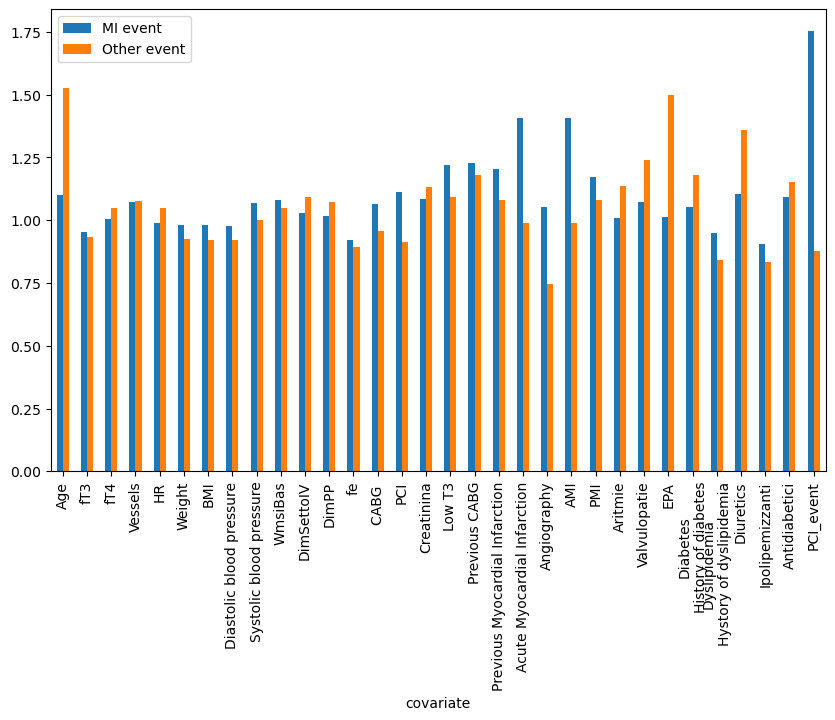

In [147]:
coef_MI = cph_MI.summary["exp(coef)"]
coef_other = cph_other.summary["exp(coef)"]
p_MI = cph_MI.summary["p"]
p_other = cph_other.summary["p"]

significant = (
    (p_MI < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "MI event": coef_MI,
    "Other event": coef_other,
    "MI event p": p_MI,
    "Other event p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["MI event","Other event"]].plot.bar(figsize=(10,6))

### Time to stroke

In [163]:
df_stroke = df_main.copy()
df_stroke["events"] = 0
df_stroke.loc[df_stroke["Ictus_event"] == 1, "events"] = 1
df_stroke.loc[df_stroke["Total mortality"] == 1, "events"] = 2

In [164]:
binary_cols = [
    col for col in df_cardiovascular.columns
    if set(df_cardiovascular[col].dropna().unique()).issubset({0,1})
]

print(binary_cols)

['Gender (Male = 1)', 'Euthyroid', 'Subclinical primary hypothyroidism (SCH)', 'Subclinical primary hyperthyroidism\n(SCT)', 'Low T3', 'Ipotiroidismo', 'Ipertiroidismo', 'Angina', 'Previous CABG', 'Previous PCI', 'Previous Myocardial Infarction', 'Acute Myocardial Infarction', 'Angiography', 'CAD', 'Documented resting \nor exertional ischemia', 'Post-ischemic Dilated\nCardiomyopathy', 'Primary Dilated\nCardiomyopathy', 'Normal', 'SindromeX', 'AMI', 'PMI', 'Aritmie', 'MIN', 'MIO', 'Miocardite', 'Pericardite', 'Endocardite', 'Valvulopatie', 'MalattiaVasoAorta', 'Ipertensione', 'EmboliaPolmonare', 'EPA', 'Smoke\nHistory of smoke', 'Diabetes\nHistory of diabetes', 'Hypertension\nHistory of hypertension', 'Dyslipidemia\nHystory of dyslipidemia', 'Atrial Fibrillation', 'B-Blockers', 'Amiodarone', 'Calcium channel blockers', 'Diuretics', 'Antiplatelet', 'Nitrates', 'ACE-inhibitors', 'Ipolipemizzanti', 'Antidiabetici', 'CABG _event', 'Non Fatal AMI (Follow-Up)_event', 'Ictus_event', 'PCI_event

In [165]:
cols_to_keep = binary_cols + ["Follow Up Data", "Data of death","Data prelievo", "events"]

tmp = df_stroke[cols_to_keep].copy()

df_stroke = df_stroke.drop(columns=cols_to_keep)

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_stroke)

df_stroke = pd.DataFrame(scaled_array, columns=df_stroke.columns, index=df_stroke.index)

df_stroke = pd.concat([df_stroke, tmp], axis=1)

df_stroke["Ictus_date"] = np.where( 
    df_stroke["Ictus_event"] == 1,
    df_stroke["Ictus"], 
    df_stroke["Follow Up Data"] )

df_stroke = df_stroke.drop(columns=[    "Fatal MI or Sudden death",  
                                "UnKnown",
                                "Total mortality", 
                                "Accident",
                                "Suicide",
                                "Number",
                                "Data prelievo",
                                "CVD Death",
                                "Data of death",
                                "Non Fatal AMI (Follow-Up)_event",
                                "Non Fatal AMI (Follow-Up)",
                                "Follow Up Data",
                                "Ictus_event",
                                "Ictus"])

print(df_stroke.info())
print(df_stroke["events"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 6264 entries, 0 to 8064
Data columns (total 74 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         6264 non-null   float64
 1   Total cholesterol                           6264 non-null   float64
 2   HDL                                         6264 non-null   float64
 3   LDL                                         6264 non-null   float64
 4   Triglycerides                               6264 non-null   float64
 5   Glycemia                                    6264 non-null   float64
 6   TSH                                         6264 non-null   float64
 7   fT3                                         6264 non-null   float64
 8   fT4                                         6264 non-null   float64
 9   Vessels                                     6264 non-null   float64
 10  HR               

In [167]:
df_temp = df_stroke.copy()
df_temp["events"] = df_temp["events"] == 1

# initialize CoxPHFitter
cph_stroke = CoxPHFitter(penalizer=0.1)

# fit
cph_stroke.fit(df_temp, duration_col="Ictus_date", event_col="events")

<lifelines.CoxPHFitter: fitted with 6264 total observations, 6206 right-censored observations>

In [168]:
df_temp = df_stroke.copy()
df_temp["events"] = df_temp["events"] == 2

# initialize CoxPHFitter
cph_other = CoxPHFitter(penalizer=0.1)

# fit
cph_other.fit(df_temp, duration_col="Ictus_date", event_col="events")

<lifelines.CoxPHFitter: fitted with 6264 total observations, 4632 right-censored observations>

In [169]:
print("Concordance index CV: ", cph_stroke.concordance_index_)
print("Concordance index Other: ", cph_other.concordance_index_)

Concordance index CV:  0.736894211352928
Concordance index Other:  0.7960317323652848


                                       Stroke event  Other event  \
covariate                                                          
Age                                        1.011825     1.528829   
fT3                                        0.996536     0.926492   
Vessels                                    1.007477     1.093467   
HR                                         0.997801     1.043121   
Weight                                     0.997369     0.930750   
BMI                                        0.992199     0.927849   
Diastolic blood pressure                   0.990780     0.915796   
DimSettoIV                                 1.017672     1.088501   
DimPP                                      1.003914     1.065930   
fe                                         1.016434     0.879154   
PCI                                        1.000083     0.921161   
Creatinina                                 0.991444     1.126986   
Previous CABG                              0.964

<Axes: xlabel='covariate'>

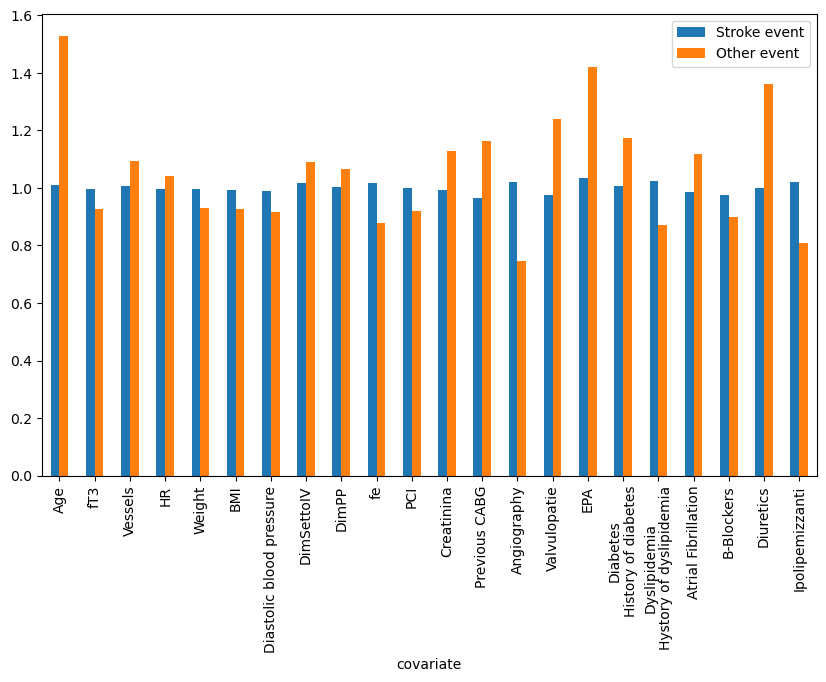

In [170]:
coef_stroke = cph_stroke.summary["exp(coef)"]
coef_other = cph_other.summary["exp(coef)"]
p_stroke = cph_stroke.summary["p"]
p_other = cph_other.summary["p"]

significant = (
    (p_stroke < 0.05) |
    (p_other < 0.05)
)

comparison = pd.DataFrame({
    "Stroke event": coef_stroke,
    "Other event": coef_other,
    "Stroke event p": p_stroke,
    "Other event p": p_other
})

comparison = comparison[significant]

print(comparison)
comparison[["Stroke event","Other event"]].plot.bar(figsize=(10,6))

In [175]:
df = pd.read_excel("Dataset Sirbu/URRAH_TG_conLegenda.xlsx",sheet_name=None)

print(df.keys()) 
df_value = df["Urrah_virdis"]
df_legend = df["Legenda"]

print(df_value.info())

dict_keys(['Urrah_virdis', 'Legenda'])
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27078 entries, 0 to 27077
Data columns (total 85 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SESSO                           27078 non-null  int64  
 1   SESSO0                          27078 non-null  object 
 2   ETA                             27074 non-null  float64
 3   FAM_IPERT                       18938 non-null  float64
 4   FAM_CV                          16383 non-null  float64
 5   DIABETE                         25902 non-null  float64
 6   FUMO_ATT                        24526 non-null  float64
 7   EXFUMO                          22055 non-null  float64
 8   ALCOOL                          19514 non-null  float64
 9   ETANOLO_G_DIE                   7230 non-null   float64
 10  ATT_FIS                         13605 non-null  float64
 11  ATT_FIS_H_SETT                  6797 non-null   float6

In [178]:
missing_percent = df_value.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

ANNI_MENOP               94.656178
CBV_BASE                 94.179777
HF_BASE                  94.179777
ALBURIA_MG_24H_30_300    92.964768
FU_NF_FA                 91.598346
                           ...    
SESSO0                    0.000000
SESSO                     0.000000
URICEMIA                  0.000000
TG                        0.000000
IPERTESO                  0.000000
Length: 80, dtype: float64


In [177]:
df_value = df_value.drop(columns=['LVH', 'IMT', 'VES', 'IMA_BASE',"ALBURIA_MG_DL"])

In [ ]:
violations = df_value[~((df_value['SESSO'] == 0) & (df_value['SESSO0'] == 'DONNA')) & ~((df_value['SESSO'] == 1) & (df_value['SESSO0'] == 'UOMO'))]

print("Rows that do not satisfy the rule:")
print(violations)

In [ ]:
import pandas as pd
from pathlib import Path

def load_mimic_dataset(data_dir, skip_tables=None):

    data_dir = Path(data_dir)
    tables = {}

    for file in data_dir.glob("*.csv"):

        table_name = file.stem.lower()

        if skip_tables and table_name in skip_tables:
            print(f"Skipping {table_name}")
            continue

        print(f"Loading {table_name}")
        tables[table_name] = pd.read_csv(file)

    return tables

In [ ]:
mimic_path = "MIMIC/MIMIC/files/mimiciii/1.4"

tables = load_mimic_dataset(
    mimic_path,
    skip_tables=["chartevents","labevents"]
)